# Práctica 1: Reconocimiento de dígitos manuscritos con extracción manual de características

El nuevo banco "First bank of Wiki" desea implementar un sistema de reconocimiento automático de cheques como el siguiente:

![texto alternativo](https://upload.wikimedia.org/wikipedia/commons/b/b9/CanadianChequeSample.png)


Actualmente, el banco cuenta con un sistema capaz de aislar los dígitos y convertirlos en imágenes de 8 x 8, pero no de reconocer de qué dígito se trata. Por esa razón, nos ha solicitado realizar un módulo capaz de reconocer dígitos manuscritos dada una imagen de 8 x 8 pixeles:


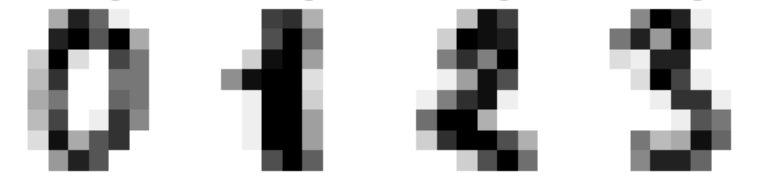



# Cargando los datos

Primero vamos a cargar el dataset y visualizar algunos dígitos.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_digits

digits = load_digits()
X, y = digits.images, digits.target

In [2]:
print(X.shape)
print(y.shape)

(1797, 8, 8)
(1797,)


In [3]:
print(X.min(),X.max())

0.0 16.0


In [4]:
print(X[0,:,:])

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


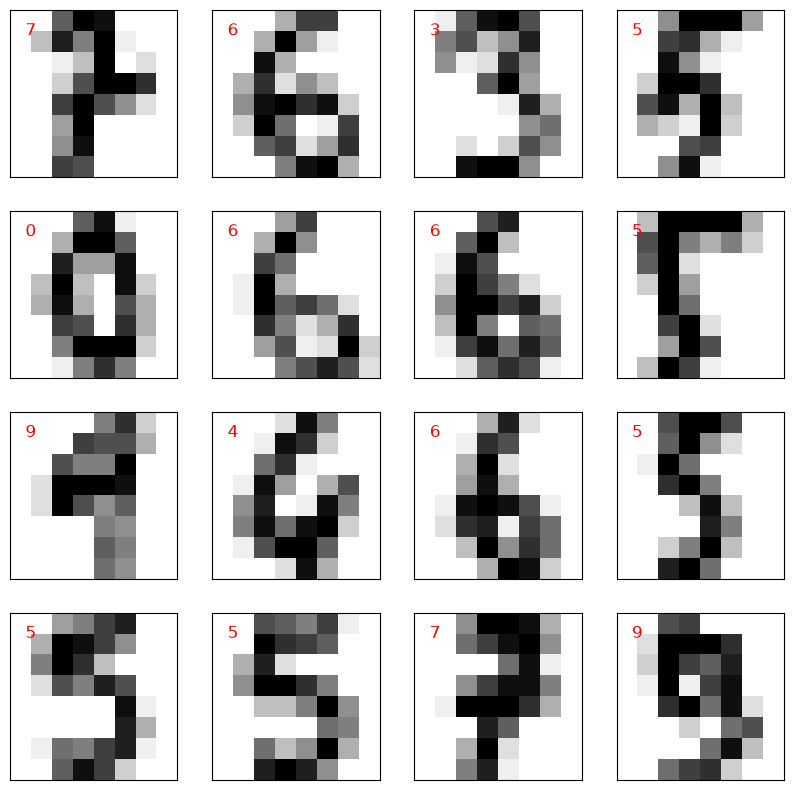

In [5]:
plt.figure(figsize=(10,10))
samples = np.random.choice(X.shape[0], 16)

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(X[samples[i],:,:], cmap=plt.get_cmap('gray_r'))
    plt.text(0.5, 0.5, str(y[samples[i]]), fontsize=12, ha='center', va='center', color='red')
    plt.xticks([])
    plt.yticks([])

# Train & Test Split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [7]:
print(f"Total de datos para clasificación entre 10 dígitos: {y.shape[0]}")

values, counts = np.unique(y_train, return_counts=True)
print(f"Datos de entrenamiento: {y_train.shape[0]}")
print(f"Datos de test: {y_test.shape[0]}")
print("Distribución de clases en el conjunto de entrenamiento:")
for value, count in zip(values, counts):
    print(f"  - {value}: {count} muestras")

Total de datos para clasificación entre 10 dígitos: 1797
Datos de entrenamiento: 1257
Datos de test: 540
Distribución de clases en el conjunto de entrenamiento:
  - 0: 125 muestras
  - 1: 132 muestras
  - 2: 130 muestras
  - 3: 129 muestras
  - 4: 121 muestras
  - 5: 116 muestras
  - 6: 128 muestras
  - 7: 124 muestras
  - 8: 131 muestras
  - 9: 121 muestras


In [11]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")

Dimensiones de X_train: (1257, 64)
Dimensiones de X_test: (540, 64)


In [9]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_transform = scaler.transform(X_train)
X_test_transform = scaler.transform(X_test) # Para el test se sugiere escalar según los datos del train 

In [ ]:
from sklearn.neural_network import MLPClassifier

# Definimos un pereceptrón multicapa con una capa oculta de 10 neuronas y un máximo de 300 iteraciones
clasificador = MLPClassifier(hidden_layer_sizes=(10,), max_iter=300, random_state=42)

# Entrenamos el clasificador
clasificador.fit(X_train, y_train)

# Imprimir la accuracy en los datos de test.
print("Accuracy en test: " + str(clasificador.score(X_test, y_test)))

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, clasificador.predict(X_test), normalize='true')

# Mostrar la matriz de confusión
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
disp.plot(cmap=plt.cm.Blues,ax=ax)

plt.show()

In [ ]:
from sklearn.metrics import recall_score, precision_score, f1_score, classification_report

# Calcular métricas de evaluación
recall = recall_score(y_test, clasificador.predict(X_test), average='weighted')
precision = precision_score(y_test, clasificador.predict(X_test), average='weighted')
f1 = f1_score(y_test, clasificador.predict(X_test), average='weighted')

print(f"Recall: {recall:.2f}")
print(f"Precision: {precision:.2f}")
print(f"F1 Score: {f1:.2f}")

# Mostrar el reporte de clasificación
print("\nClassification Report:")
print(classification_report(y_test, clasificador.predict(X_test), target_names=np.unique(y_test.astype(str))))

# Entregable:

Emplear redes neuronales para la predicción de los tipos de cobertura para los datos de la zona del dique Roggero.

 1. Realizar un análisis exploratorio de los datos, y estandarizar/normalizar las variables en caso de ser necesario.
 2. Diseñar al menos 3 arquitecturas diferentes de redes con complejidades apreciablemente diferentes.
 3. Comparar los resultados (i.e. comparar las métricas accuracy, f1_score, recall, precision) con los obtenidos empleando los 3 métodos aprendidos en la clase de aprendizaje supervisado.